In [ ]:
from google.colab import files
uploaded = files.upload()
# Upload archive__6_.zip and archive__7_.zip

Saving archive (7).zip to archive (7).zip
Saving archive (6).zip to archive (6).zip


In [ ]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Extract both zips
with zipfile.ZipFile('archive (6).zip', 'r') as z:
    z.extractall('.')
with zipfile.ZipFile('archive (7).zip', 'r') as z:
    z.extractall('.')

# Load datasets
airbnb = pd.read_csv('AB_NYC_2019.csv')
youtube = pd.read_csv('USvideos.csv', encoding='utf-8', on_bad_lines='skip')

print("=== Airbnb Dataset ===")
print("Shape:", airbnb.shape)
print(airbnb.head(3))

print("\n=== YouTube Dataset ===")
print("Shape:", youtube.shape)
print(youtube.head(3))

=== Airbnb Dataset ===
Shape: (48895, 16)
     id                                 name  host_id  host_name  \
0  2539   Clean & quiet apt home by the park     2787       John   
1  2595                Skylit Midtown Castle     2845   Jennifer   
2  3647  THE VILLAGE OF HARLEM....NEW YORK !     4632  Elisabeth   

  neighbourhood_group neighbourhood  latitude  longitude        room_type  \
0            Brooklyn    Kensington  40.64749  -73.97237     Private room   
1           Manhattan       Midtown  40.75362  -73.98377  Entire home/apt   
2           Manhattan        Harlem  40.80902  -73.94190     Private room   

   price  minimum_nights  number_of_reviews last_review  reviews_per_month  \
0    149               1                  9  2018-10-19               0.21   
1    225               1                 45  2019-05-21               0.38   
2    150               3                  0         NaN                NaN   

   calculated_host_listings_count  availability_365  
0        

In [ ]:
print("=== AIRBNB DATA INTEGRITY ===")
print("\nColumn Names:")
print(airbnb.columns.tolist())
print("\nData Types:")
print(airbnb.dtypes)

print("\n=== YOUTUBE DATA INTEGRITY ===")
print("\nColumn Names:")
print(youtube.columns.tolist())
print("\nData Types:")
print(youtube.dtypes)

=== AIRBNB DATA INTEGRITY ===

Column Names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data Types:
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object



In [ ]:
print("=== AIRBNB MISSING VALUES ===")
missing_airbnb = airbnb.isnull().sum()
missing_airbnb_pct = (airbnb.isnull().sum() / len(airbnb)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_airbnb,
    'Missing %': missing_airbnb_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

print("\n=== YOUTUBE MISSING VALUES ===")
missing_youtube = youtube.isnull().sum()
missing_youtube_pct = (youtube.isnull().sum() / len(youtube)) * 100
missing_df2 = pd.DataFrame({
    'Missing Count': missing_youtube,
    'Missing %': missing_youtube_pct
})
print(missing_df2[missing_df2['Missing Count'] > 0])

=== AIRBNB MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

=== YOUTUBE MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [ ]:
# AIRBNB
print("Airbnb shape before cleaning:", airbnb.shape)

# Fill missing reviews_per_month with 0
airbnb['reviews_per_month'] = airbnb['reviews_per_month'].fillna(0)

# Fill missing name and host_name with Unknown
airbnb['name'] = airbnb['name'].fillna('Unknown')
airbnb['host_name'] = airbnb['host_name'].fillna('Unknown')

# Fill missing last_review with Not Reviewed
airbnb['last_review'] = airbnb['last_review'].fillna('Not Reviewed')

print("Missing values after cleaning:")
print(airbnb.isnull().sum())

# YOUTUBE
print("\nYouTube shape before cleaning:", youtube.shape)
youtube['description'] = youtube['description'].fillna('No Description')
print("YouTube missing after cleaning:")
print(youtube.isnull().sum())

Airbnb shape before cleaning: (48895, 16)
Missing values after cleaning:
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

YouTube shape before cleaning: (40901, 16)
YouTube missing after cleaning:
video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes  

In [ ]:
print("=== DUPLICATE REMOVAL ===")

print("\nAirbnb duplicates before:", airbnb.duplicated().sum())
airbnb = airbnb.drop_duplicates()
print("Airbnb duplicates after:", airbnb.duplicated().sum())
print("Airbnb shape after:", airbnb.shape)

print("\nYouTube duplicates before:", youtube.duplicated().sum())
youtube = youtube.drop_duplicates()
print("YouTube duplicates after:", youtube.duplicated().sum())
print("YouTube shape after:", youtube.shape)

=== DUPLICATE REMOVAL ===

Airbnb duplicates before: 0
Airbnb duplicates after: 0
Airbnb shape after: (48895, 16)

YouTube duplicates before: 48
YouTube duplicates after: 0
YouTube shape after: (40901, 16)


In [ ]:
print("=== STANDARDIZATION ===")

# Airbnb - standardize text columns to lowercase
airbnb['neighbourhood_group'] = airbnb['neighbourhood_group'].str.strip().str.title()
airbnb['room_type'] = airbnb['room_type'].str.strip().str.title()

print("Unique neighbourhood groups:", airbnb['neighbourhood_group'].unique())
print("Unique room types:", airbnb['room_type'].unique())

# YouTube - standardize boolean columns
youtube['comments_disabled'] = youtube['comments_disabled'].astype(str).str.strip()
youtube['ratings_disabled'] = youtube['ratings_disabled'].astype(str).str.strip()

print("\nComments disabled values:", youtube['comments_disabled'].unique())
print("Ratings disabled values:", youtube['ratings_disabled'].unique())

=== STANDARDIZATION ===
Unique neighbourhood groups: ['Brooklyn' 'Manhattan' 'Queens' 'Staten Island' 'Bronx']
Unique room types: ['Private Room' 'Entire Home/Apt' 'Shared Room']

Comments disabled values: ['False' 'True']
Ratings disabled values: ['False' 'True']


In [ ]:
print("=== OUTLIER DETECTION ===")

# Airbnb price outliers
Q1 = airbnb['price'].quantile(0.25)
Q3 = airbnb['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = airbnb[(airbnb['price'] < lower) | (airbnb['price'] > upper)]
print(f"\nAirbnb Price Outliers: {len(outliers)} rows")
print(f"Price range: Min={airbnb['price'].min()}, Max={airbnb['price'].max()}")
print(f"Normal range: {lower:.0f} to {upper:.0f}")

# YouTube views outliers
Q1v = youtube['views'].quantile(0.25)
Q3v = youtube['views'].quantile(0.75)
IQRv = Q3v - Q1v
outliers_yt = youtube[(youtube['views'] < Q1v - 1.5*IQRv) |
                      (youtube['views'] > Q3v + 1.5*IQRv)]
print(f"\nYouTube Views Outliers: {len(outliers_yt)} rows")
print(f"Views range: Min={youtube['views'].min()}, Max={youtube['views'].max()}")

=== OUTLIER DETECTION ===

Airbnb Price Outliers: 2972 rows
Price range: Min=0, Max=10000
Normal range: -90 to 334

YouTube Views Outliers: 4497 rows
Views range: Min=549, Max=225211923


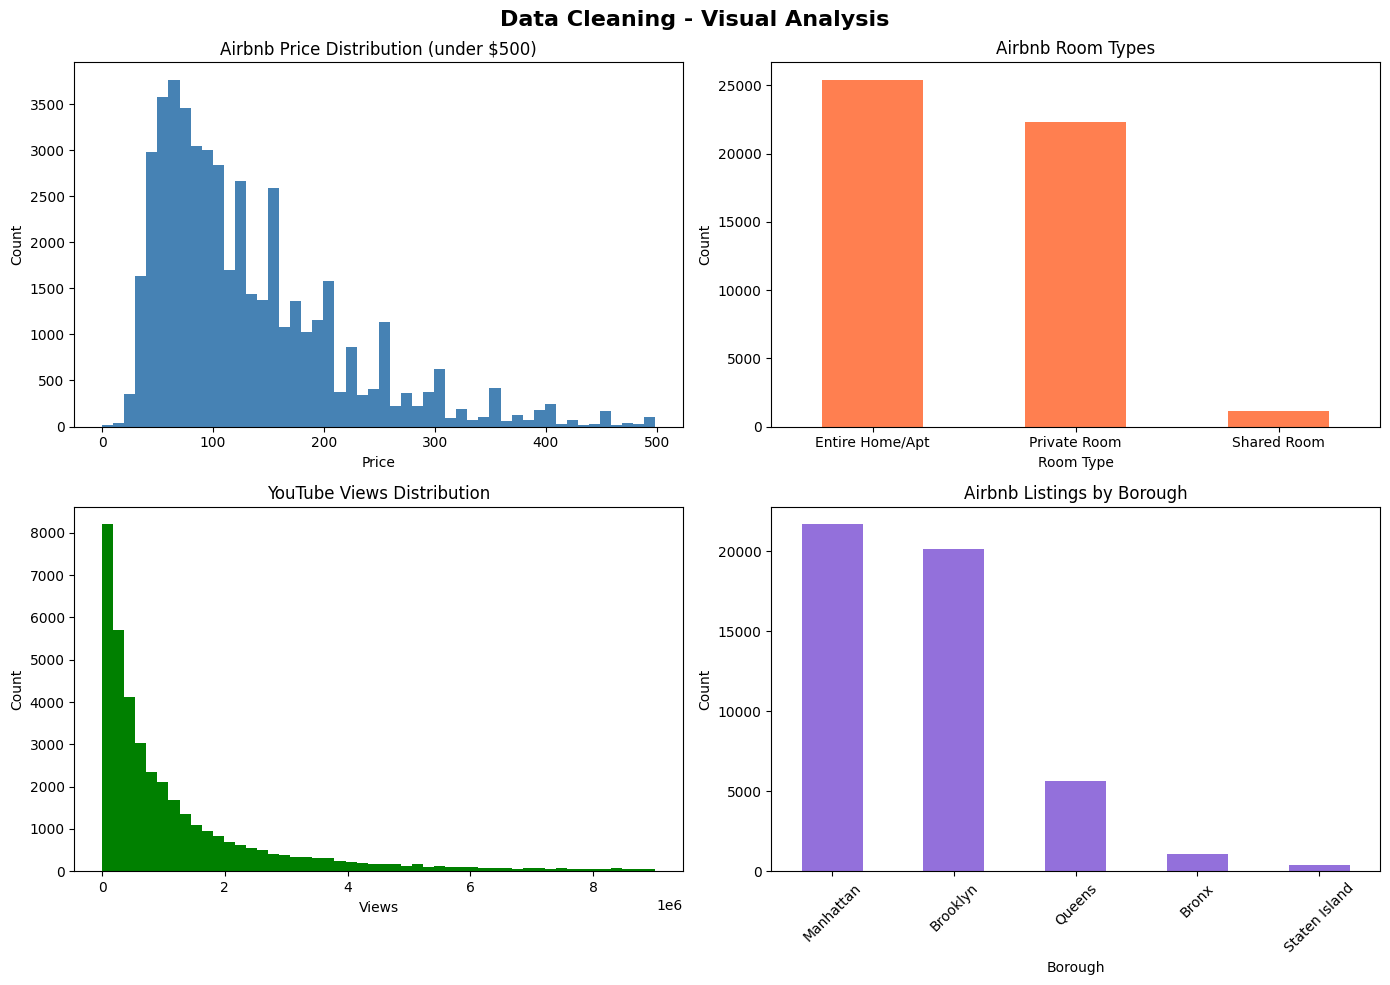

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 - Airbnb price distribution (remove extreme outliers for visualization)
airbnb_filtered = airbnb[airbnb['price'] < 500]
axes[0,0].hist(airbnb_filtered['price'], bins=50, color='steelblue')
axes[0,0].set_title('Airbnb Price Distribution (under $500)')
axes[0,0].set_xlabel('Price')
axes[0,0].set_ylabel('Count')

# Chart 2 - Airbnb room type count
airbnb['room_type'].value_counts().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Airbnb Room Types')
axes[0,1].set_xlabel('Room Type')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=0)

# Chart 3 - YouTube views distribution
youtube_filtered = youtube[youtube['views'] < youtube['views'].quantile(0.95)]
axes[1,0].hist(youtube_filtered['views'], bins=50, color='green')
axes[1,0].set_title('YouTube Views Distribution')
axes[1,0].set_xlabel('Views')
axes[1,0].set_ylabel('Count')

# Chart 4 - Airbnb neighbourhood group
airbnb['neighbourhood_group'].value_counts().plot(
    kind='bar', ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('Airbnb Listings by Borough')
axes[1,1].set_xlabel('Borough')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Data Cleaning - Visual Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

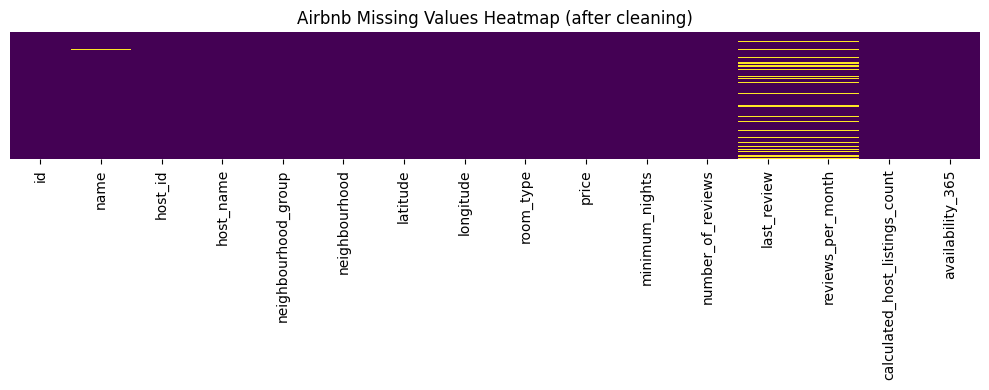

In [ ]:
plt.figure(figsize=(10, 4))
sns.heatmap(airbnb.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Airbnb Missing Values Heatmap (after cleaning)')
plt.tight_layout()
plt.show()

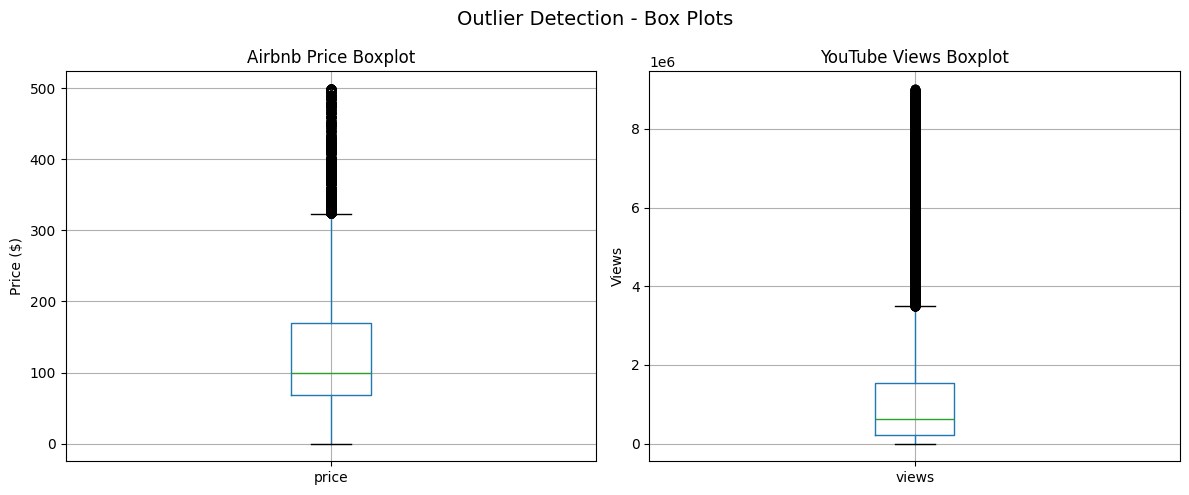

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Airbnb price boxplot
airbnb[airbnb['price'] < 500].boxplot(column='price', ax=axes[0])
axes[0].set_title('Airbnb Price Boxplot')
axes[0].set_ylabel('Price ($)')

# YouTube views boxplot
youtube[youtube['views'] < youtube['views'].quantile(0.95)].boxplot(
    column='views', ax=axes[1])
axes[1].set_title('YouTube Views Boxplot')
axes[1].set_ylabel('Views')

plt.suptitle('Outlier Detection - Box Plots', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
print("=== FINAL DATA CLEANING SUMMARY ===\n")

print("AIRBNB DATASET:")
print(f"  Final shape: {airbnb.shape}")
print(f"  Missing values: {airbnb.isnull().sum().sum()}")
print(f"  Duplicates: {airbnb.duplicated().sum()}")
print(f"  Price range after cleaning: ${airbnb['price'].min()} - ${airbnb['price'].max()}")

print("\nYOUTUBE DATASET:")
print(f"  Final shape: {youtube.shape}")
print(f"  Missing values: {youtube.isnull().sum().sum()}")
print(f"  Duplicates: {youtube.duplicated().sum()}")
print(f"  Views range: {youtube['views'].min()} - {youtube['views'].max()}")

print("\nCLEANING STEPS COMPLETED:")
print("  ✅ 1. Data Integrity Check")
print("  ✅ 2. Missing Values Handled")
print("  ✅ 3. Duplicates Removed")
print("  ✅ 4. Standardization Done")
print("  ✅ 5. Outliers Detected")
print("  ✅ 6. Visualizations Created")
print("\nData is now clean and ready for analysis! 🎉")

=== FINAL DATA CLEANING SUMMARY ===

AIRBNB DATASET:
  Final shape: (48895, 16)
  Missing values: 20141
  Duplicates: 0
  Price range after cleaning: $0 - $10000

YOUTUBE DATASET:
  Final shape: (40901, 16)
  Missing values: 569
  Duplicates: 0
  Views range: 549 - 225211923

CLEANING STEPS COMPLETED:
  ✅ 1. Data Integrity Check
  ✅ 2. Missing Values Handled
  ✅ 3. Duplicates Removed
  ✅ 4. Standardization Done
  ✅ 5. Outliers Detected
  ✅ 6. Visualizations Created

Data is now clean and ready for analysis! 🎉
